# `PyTorch` without `torchvision`

Legacy educational CNN on a tiny flower-photo subset. Paths are local (`pytorch_classification/data/flower_photos_mini`); no Colab / Drive mount required.


### (i) Preprocessor and Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from skimage.io import imread
from skimage.transform import resize
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from torch import nn
from torch.nn import BatchNorm2d, Conv2d, CrossEntropyLoss, Linear, MaxPool2d, ReLU, Sequential
from torch.optim import Adam
from tqdm import tqdm

DATA_ROOT = Path("data/flower_photos_mini")
TRAIN_DIR = DATA_ROOT / "training_set"
TEST_DIR = DATA_ROOT / "test_set"
IMG_SIZE = 28
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

In [2]:
train = pd.read_csv(TRAIN_DIR / "training.csv")
label_map = {"tulips": 0, "daisy": 1, "dandelion": 2, "sunflowers": 3, "roses": 4}
train = train.rename(columns={"Id": "id"})
train["label"] = train["label"].map(label_map)
train.head()


,label,id,image_type
0,1,3445110406_0c1616d2e3_n,.jpg
1,1,147068564_32bb4350cc,.jpg
2,1,6884975451_c74f445d69_m,.jpg
3,1,12348343085_d4c396e5b5_m,.jpg
4,1,8489463746_a9839bf7e4,.jpg


#### Preprocessor

In [3]:
def preprocessor(data_path: Path, labels_df: pd.DataFrame) -> list[np.ndarray]:
    """Read images, resize to a fixed shape, and min-max scale to [0, 1].

    Parameters
    ----------
    data_path:
        Directory containing image files.
    labels_df:
        DataFrame with columns ``id`` and ``image_type`` (extension).

    Returns
    -------
    list[np.ndarray]
        List of float32 HWC arrays.
    """
    images: list[np.ndarray] = []
    for _, row in tqdm(labels_df.iterrows(), total=len(labels_df)):
        path = data_path / f"{row['id']}{row['image_type']}"
        img = imread(path)
        img = resize(img, (IMG_SIZE, IMG_SIZE, 3), anti_aliasing=True)
        img = img.astype("float32")
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        images.append(img)
    return images

train_x = np.asarray(preprocessor(TRAIN_DIR, train), dtype=np.float32)
train_y = train["label"].to_numpy(dtype=np.int64)
train_x.shape, train_y.shape


  0%|          | 0/25 [00:00<?, ?it/s]

 44%|████▍     | 11/25 [00:00<00:00, 96.44it/s]

 84%|████████▍ | 21/25 [00:00<00:00, 97.07it/s]

100%|██████████| 25/25 [00:00<00:00, 93.77it/s]

((25, 28, 28, 3), (25,))

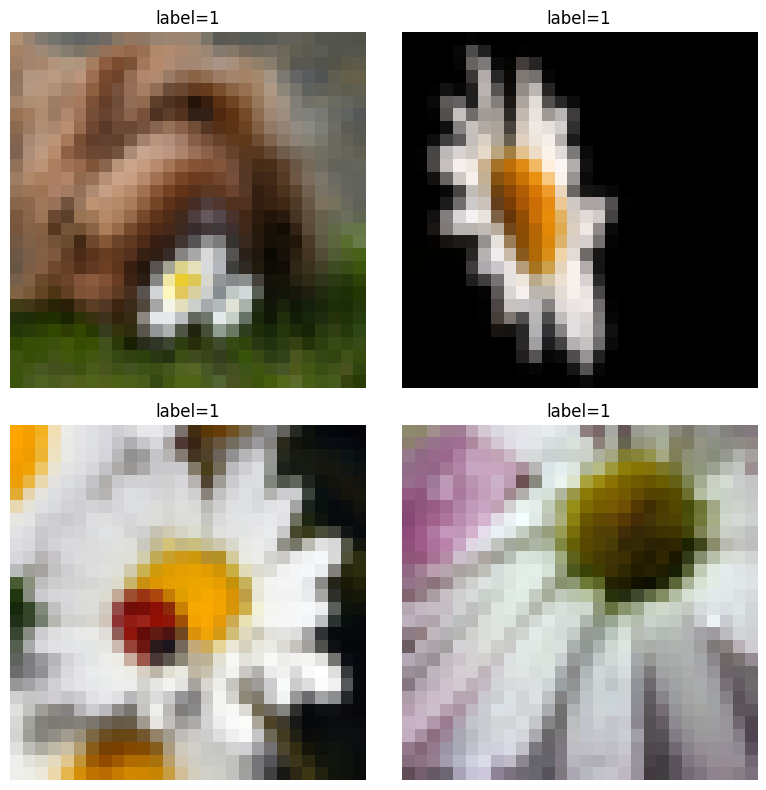

In [4]:
i = 0
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
for ax in axes.ravel():
    ax.imshow(train_x[i])
    ax.set_title(f"label={train_y[i]}")
    ax.axis("off")
    i += 1
plt.tight_layout()
plt.show()


In [5]:
train_x, test_x, train_y, test_y = train_test_split(
    train_x, train_y, test_size=0.2, random_state=SEED, stratify=train_y
)
train_x.shape, test_x.shape, train_y.shape, test_y.shape


((20, 28, 28, 3), (5, 28, 28, 3), (20,), (5,))

In [6]:
# NHWC -> NCHW tensors
train_x_t = torch.from_numpy(np.transpose(train_x, (0, 3, 1, 2)))
test_x_t = torch.from_numpy(np.transpose(test_x, (0, 3, 1, 2)))
train_y_t = torch.from_numpy(train_y)
test_y_t = torch.from_numpy(test_y)
train_x_t.shape, train_y_t.shape, test_x_t.shape, test_y_t.shape


(torch.Size([20, 3, 28, 28]),
 torch.Size([20]),
 torch.Size([5, 3, 28, 28]),
 torch.Size([5]))

### (ii) Train Model Using `torch`

In [7]:
class Net(nn.Module):
    def __init__(self, n_classes: int = 5) -> None:
        super().__init__()
        self.cnn_layers = Sequential(
            Conv2d(3, 4, kernel_size=3, stride=1, padding=1),
            BatchNorm2d(4),
            ReLU(inplace=True),
            MaxPool2d(kernel_size=2, stride=2),
            Conv2d(4, 4, kernel_size=3, stride=1, padding=1),
            BatchNorm2d(4),
            ReLU(inplace=True),
            MaxPool2d(kernel_size=2, stride=2),
        )
        # 28 -> 14 -> 7 spatial size after two stride-2 pools
        self.linear_layers = Sequential(Linear(4 * 7 * 7, n_classes))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.cnn_layers(x)
        x = x.reshape(x.size(0), -1)
        return self.linear_layers(x)

model = Net().to(device)
optimizer = Adam(model.parameters(), lr=1e-2)
criterion = CrossEntropyLoss()
print(model)


Net(
  (cnn_layers): Sequential(
    (0): Conv2d(3, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(4, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (linear_layers): Sequential(
    (0): Linear(in_features=196, out_features=5, bias=True)
  )
)


In [8]:
def run_epoch(x: torch.Tensor, y: torch.Tensor, train_mode: bool) -> tuple[float, float]:
    if train_mode:
        model.train()
    else:
        model.eval()
    x = x.to(device)
    y = y.to(device)
    with torch.set_grad_enabled(train_mode):
        logits = model(x)
        loss = criterion(logits, y)
        if train_mode:
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()
    preds = logits.argmax(dim=1)
    acc = (preds == y).float().mean().item()
    return loss.item(), acc

n_epochs = 40
train_losses: list[float] = []
test_losses: list[float] = []
for epoch in range(n_epochs):
    tr_loss, tr_acc = run_epoch(train_x_t, train_y_t, train_mode=True)
    te_loss, te_acc = run_epoch(test_x_t, test_y_t, train_mode=False)
    train_losses.append(tr_loss)
    test_losses.append(te_loss)
    if epoch % 5 == 0 or epoch == n_epochs - 1:
        print(
            f"epoch={epoch+1:02d}  train_loss={tr_loss:.3f}  val_loss={te_loss:.3f}  "
            f"train_acc={tr_acc:.2f}  val_acc={te_acc:.2f}"
        )


epoch=01  train_loss=1.759  val_loss=1.603  train_acc=0.25  val_acc=0.20
epoch=06  train_loss=0.720  val_loss=1.511  train_acc=0.85  val_acc=0.40
epoch=11  train_loss=0.205  val_loss=1.474  train_acc=1.00  val_acc=0.40
epoch=16  train_loss=0.052  val_loss=1.576  train_acc=1.00  val_acc=0.40
epoch=21  train_loss=0.015  val_loss=1.567  train_acc=1.00  val_acc=0.40
epoch=26  train_loss=0.006  val_loss=1.545  train_acc=1.00  val_acc=0.40
epoch=31  train_loss=0.003  val_loss=1.547  train_acc=1.00  val_acc=0.40
epoch=36  train_loss=0.002  val_loss=1.627  train_acc=1.00  val_acc=0.20
epoch=40  train_loss=0.001  val_loss=1.765  train_acc=1.00  val_acc=0.40


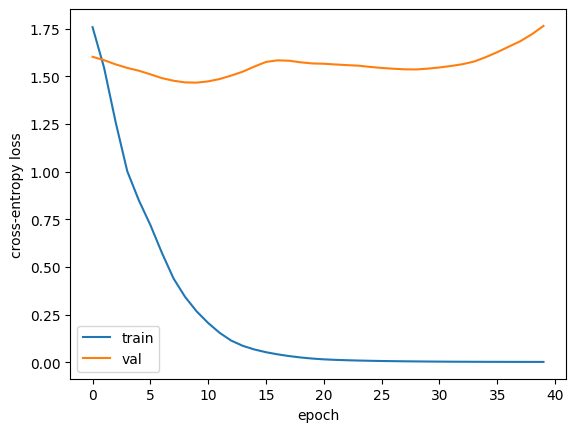

train accuracy (split) 1.0
val accuracy (split) 0.4


  0%|          | 0/15 [00:00<?, ?it/s]

100%|██████████| 15/15 [00:00<00:00, 147.53it/s]

100%|██████████| 15/15 [00:00<00:00, 146.93it/s]

holdout accuracy (test_set) 0.13333333333333333


In [9]:
plt.plot(train_losses, label="train")
plt.plot(test_losses, label="val")
plt.xlabel("epoch")
plt.ylabel("cross-entropy loss")
plt.legend()
plt.show()

model.eval()
with torch.no_grad():
    train_pred = model(train_x_t.to(device)).argmax(dim=1).cpu().numpy()
    val_pred = model(test_x_t.to(device)).argmax(dim=1).cpu().numpy()
print("train accuracy (split)", accuracy_score(train_y, train_pred))
print("val accuracy (split)", accuracy_score(test_y, val_pred))

# True holdout shipped in test_set/
holdout = pd.read_csv(TEST_DIR / "testing.csv").rename(columns={"Id": "id"})
holdout["label"] = holdout["label"].map(label_map)
holdout_x = np.asarray(preprocessor(TEST_DIR, holdout), dtype=np.float32)
holdout_y = holdout["label"].to_numpy(dtype=np.int64)
holdout_x_t = torch.from_numpy(np.transpose(holdout_x, (0, 3, 1, 2)))
with torch.no_grad():
    holdout_pred = model(holdout_x_t.to(device)).argmax(dim=1).cpu().numpy()
print("holdout accuracy (test_set)", accuracy_score(holdout_y, holdout_pred))


### Notes

- Labels are **0-indexed** (required by `CrossEntropyLoss`); the legacy notebook used 1–5.
- Learning rate is lower than the original `0.07`, which was unstable on this architecture.
- Training monitors an 80/20 split of `training_set`; final **holdout** accuracy uses `test_set/testing.csv`.
- `flower_photos_mini` is intentionally tiny (demo / CI-friendly). Point `DATA_ROOT` at a larger local extract with the same CSV layout to scale up.
